<a href="https://colab.research.google.com/github/giankev/lightweight-model-for-signal-processing/blob/ofdm-case/dataset_comunication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install sionna tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.4/520.4 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.4 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextens

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Any, Optional
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import sionna
from sionna.phy.mapping import Constellation, Mapper, Demapper
from sionna.phy.channel import AWGN
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.ofdm.modulator import OFDMModulator
from sionna.phy.ofdm.demodulator import OFDMDemodulator

# Sionna global RNG seed (for AWGN reproducibility)
try:
    from sionna.phy import config as sn_config
except Exception:
    sn_config = None


# =============================================================================
# Config
# =============================================================================
@dataclass(frozen=True)
class SimConfig:
    """
    Single-carrier symbol-rate generator: 16-QAM + LDPC + pilots + (CFO-like ramp + AWGN).

    Per-sample (aka per-frame) model:
      x_tx = [pilots(P), data(L)]  -> total T=P+L symbols
      y[t] = x_tx[t] * exp(j*(phi0 + 2*pi*cfo_norm*t)) + w_awgn[t]

    Notes:
      - "cfo_norm" here is normalized CFO in cycles/symbol (your previous "cto_norm").
        Phase increment per symbol = 2*pi*cfo_norm.
      - Eb/N0 is defined w.r.t. information bits; pilot overhead accounted via (P+L)/L.
    """

    # Dataset size (N samples/frames)
    num_examples: int = 10_000

    # Modulation
    seq_length: int = 128            # L data symbols
    bits_per_symbol: int = 4         # m=4 -> 16-QAM

    # LDPC (5G)
    k: int = 256                     # info bits per sample; coded bits n=L*m

    # Pilots
    pilot_len: int = 16              # P pilot symbols
    pilot_seed: int = 999            # deterministic pilot bits

    # Channel: Eb/N0 range (info-bit)
    ebn0_db_min: float = 0.0
    ebn0_db_max: float = 10.0

    # Impairments ranges
    phase_min: float = -np.pi
    phase_max: float = np.pi
    cfo_norm_min: float = -0.002     # cycles/symbol
    cfo_norm_max: float = 0.002

    # Receiver blocks
    demap_method: str = "app"        # "app" or "maxlog"
    dec_num_iter: int = 20
    cn_update: str = "minsum"

    # Reproducibility (controls TF generator + Sionna global RNG)
    seed: int = 46
    seed_noise: Optional[int] = None  # AWGN; None ->  seed
    llr_noise_scaling: float = 1.0    # alpha >= 1 LLR (vedi)

    # Waveform selection: "sc" (single-carrier) or "ofdm"
    waveform: str = "sc"

    # Pilot constellation (recommended QPSK pilots even if data is 16-QAM)
    pilot_bits_per_symbol: int = 2  # 2->QPSK, 4->16-QAM

    # OFDM parameters (used only if waveform=="ofdm")
    ofdm_fft_size: int = 64
    ofdm_cp_len: int = 16
    ofdm_num_pilot_symbols: int = 1   # number of pilot OFDM symbols (block pilots)
    ofdm_num_data_symbols: int = 2    # number of data OFDM symbols
    ofdm_l_min: int = 0               # for OFDMDemodulator; keep 0 for pure AWGN/time-domain impairments

    # Format
    channels_last: bool = True       # IQ format: [N,T,2] if True else [N,2,T]
    tf_rdtype: tf.dtypes.DType = tf.float32
    tf_cdtype: tf.dtypes.DType = tf.complex64


# =============================================================================
# Helpers
# =============================================================================
def set_global_seed(seed: int, seed_sionna: Optional[int] = None) -> None:
    """Best-effort reproducibility across TF + Sionna internal RNG + numpy."""
    np.random.seed(seed)
    tf.random.set_seed(seed)
    if sn_config is not None and seed_sionna is not None:
        sn_config.seed = int(seed_sionna)

def complex_to_2ch_real(x: tf.Tensor, channels_last: bool) -> tf.Tensor:
    """Convert complex [...,T] -> real IQ [...,T,2] or [...,2,T]."""
    i = tf.math.real(x)
    q = tf.math.imag(x)
    return tf.stack([i, q], axis=-1 if channels_last else -2)


def expj(theta: tf.Tensor, cdtype: tf.DType) -> tf.Tensor:
    """exp(j*theta) with complex dtype."""
    return tf.cast(tf.complex(tf.math.cos(theta), tf.math.sin(theta)), cdtype)

def simulate_full_frames_tf(cfg: SimConfig) -> Dict[str, Any]:
    if cfg.waveform.lower() == "sc":
        return simulate_full_frames_sc_tf(cfg)
    if cfg.waveform.lower() == "ofdm":
        return simulate_full_frames_ofdm_tf(cfg)
    raise ValueError(f"Unknown waveform={cfg.waveform}. Use 'sc' or 'ofdm'.")

def build_sionna_blocks(cfg: SimConfig):
    """Create modulation/coding/channel blocks."""
    m = cfg.bits_per_symbol
    constellation = Constellation("qam", num_bits_per_symbol=m)
    mapper = Mapper(constellation=constellation)
    demapper = Demapper(cfg.demap_method, constellation=constellation)
    awgn = AWGN()
    n = cfg.seq_length * cfg.bits_per_symbol
    encoder = LDPC5GEncoder(k=cfg.k, n=n, num_bits_per_symbol=m)
    decoder = LDPC5GDecoder(
        encoder=encoder,
        num_iter=cfg.dec_num_iter,
        return_infobits=True,
        hard_out=True,
        cn_update=cfg.cn_update,
    )
    return constellation, mapper, demapper, awgn, encoder, decoder


def make_deterministic_symbols_tf(cfg: SimConfig,
                                  N: int,
                                  num_symbols: int,
                                  bits_per_symbol: int,
                                  seed: int) -> Dict[str, tf.Tensor]:
    """Create deterministic bits and mapped QAM symbols (same for all samples)."""
    rng = tf.random.Generator.from_seed(int(seed))

    bits = rng.uniform([num_symbols * bits_per_symbol],
                       minval=0, maxval=2, dtype=tf.int32)  # [num_symbols*bps]

    const = Constellation("qam", num_bits_per_symbol=int(bits_per_symbol))
    mapper = Mapper(constellation=const)

    x1 = tf.cast(mapper(tf.reshape(bits, [1, num_symbols * bits_per_symbol])),
                 cfg.tf_cdtype)  # [1,num_symbols]
    x = tf.tile(x1, [N, 1])       # [N,num_symbols]
    return {"bits": bits, "x": x}


# =============================================================================
# TX + Channel (single source of truth)
# =============================================================================
def simulate_full_frames_ofdm_tf(cfg: SimConfig) -> Dict[str, Any]:
    """
    OFDM frame:
      - First: cfg.ofdm_num_pilot_symbols OFDM symbols fully populated with pilots
      - Then:  cfg.ofdm_num_data_symbols OFDM symbols fully populated with coded QAM data
    Impairments applied in time domain:
      y[n] = x[n] * exp(j*(phi0 + 2*pi*cfo_norm*n)) + w[n]
    """
    set_global_seed(cfg.seed)
    rng = tf.random.Generator.from_seed(cfg.seed)

    N = int(cfg.num_examples)
    m = int(cfg.bits_per_symbol)
    k = int(cfg.k)

    fft_size = int(cfg.ofdm_fft_size)
    cp_len = int(cfg.ofdm_cp_len)
    n_pilot_sym = int(cfg.ofdm_num_pilot_symbols)
    n_data_sym = int(cfg.ofdm_num_data_symbols)
    n_total_sym = n_pilot_sym + n_data_sym

    # Data QAM symbols per frame = n_data_sym * fft_size
    L = int(cfg.seq_length)
    if L != n_data_sym * fft_size:
        raise ValueError(f"OFDM requires seq_length = ofdm_num_data_symbols*ofdm_fft_size "
                         f"({n_data_sym}*{fft_size}={n_data_sym*fft_size}), got {L}.")
    n = L * m
    if not (0 < k < n):
        raise ValueError(f"Invalid k={k}. Must satisfy 0 < k < n={n}.")

    R = float(k) / float(n)

    # Coding + mapping (data)
    _, mapper_data, _, awgn, encoder, _ = build_sionna_blocks(cfg)
    info_bits = rng.uniform([N, k], minval=0, maxval=2, dtype=tf.int32)               # [N,k]
    coded_bits_f = encoder(tf.cast(info_bits, cfg.tf_rdtype))                         # [N,n] float {0,1}
    coded_bits = tf.cast(coded_bits_f, tf.int32)

    x_data_flat = tf.cast(mapper_data(coded_bits), cfg.tf_cdtype)                     # [N,L]
    x_data_grid = tf.reshape(x_data_flat, [N, n_data_sym, fft_size])                  # [N,n_data_sym,fft_size]

    # Pilot symbols (frequency domain), deterministic
    pilot_bps = int(cfg.pilot_bits_per_symbol)
    pilot_pack = make_deterministic_symbols_tf(
        cfg, N=N,
        num_symbols=n_pilot_sym * fft_size,
        bits_per_symbol=pilot_bps,
        seed=int(cfg.pilot_seed)
    )
    pilot_bits = pilot_pack["bits"]                                                   # [n_pilot_sym*fft_size*pilot_bps]
    x_pilot_grid = tf.reshape(pilot_pack["x"], [N, n_pilot_sym, fft_size])            # [N,n_pilot_sym,fft_size]

    # Full OFDM resource grid (freq domain)
    x_grid = tf.concat([x_pilot_grid, x_data_grid], axis=1)                           # [N,n_total_sym,fft_size]

    # OFDM modulation (ifftshift + unitary ifft + CP) :contentReference[oaicite:3]{index=3}
    mod = OFDMModulator(cyclic_prefix_length=cp_len)
    x_time = tf.cast(mod(x_grid), cfg.tf_cdtype)                                      # [N, n_total_sym*(fft_size+cp_len)]

    # Time-domain pilots for CFO/CPE estimation: first n_pilot_sym OFDM symbols (incl. CP)
    P_time = n_pilot_sym * (fft_size + cp_len)
    x_pilot_time = x_time[:, :P_time]                                                 # [N,P_time]

    # Impairments: phase + CFO ramp in time samples
    T_time = int(n_total_sym * (fft_size + cp_len))
    phi0 = rng.uniform([N, 1], minval=cfg.phase_min, maxval=cfg.phase_max, dtype=cfg.tf_rdtype)   # [N,1]
    cfo = rng.uniform([N, 1], minval=cfg.cfo_norm_min, maxval=cfg.cfo_norm_max, dtype=cfg.tf_rdtype)  # [N,1]
    t = tf.range(T_time, dtype=cfg.tf_rdtype)[None, :]                                # [1,T_time]
    phi_total = phi0 + tf.constant(2.0*np.pi, cfg.tf_rdtype) * cfo * t                # [N,T_time]
    x_tx = x_time
    x_tx_phase = x_tx * expj(phi_total, cfg.tf_cdtype)

    # Eb/N0 -> complex noise variance per time sample
    ebn0_db = rng.uniform([N], minval=cfg.ebn0_db_min, maxval=cfg.ebn0_db_max, dtype=cfg.tf_rdtype)
    ebn0_lin = tf.pow(tf.constant(10.0, cfg.tf_rdtype), ebn0_db / 10.0)

    # Overhead: total time samples / data QAM symbols (=seq_length)
    overhead = tf.constant(T_time / float(L), dtype=cfg.tf_rdtype)

    es = tf.reduce_mean(tf.abs(x_tx_phase) ** 2, axis=1, keepdims=True)               # [N,1]
    no = es / (tf.reshape(ebn0_lin, [-1, 1]) * (m * R)) * overhead                    # [N,1]

    y_rx = tf.cast(awgn(x_tx_phase, no), cfg.tf_cdtype)                               # [N,T_time]

    return {
        "info_bits": info_bits,
        "coded_bits": coded_bits,
        "pilot_bits": pilot_bits,
        "x_pilot": x_pilot_time,   # time-domain reference pilots for CFO/CPE estimation
        "x_data": x_data_flat,     # transmitted data symbols in freq-domain, flattened [N,L]
        "x_tx": x_tx,              # time-domain transmitted samples (without impairments)
        "y_rx": y_rx,              # time-domain received samples
        "phi0": phi0,
        "cfo_norm": cfo,
        "ebn0_db": ebn0_db,
        "no": no,
        "meta": {
            "waveform": "ofdm",
            "N": N,
            "m": m,
            "k": k,
            "n": n,
            "R": float(R),
            "L": L,                         # number of data QAM symbols
            "P": int(P_time),               # number of pilot time samples
            "T": int(T_time),               # number of total time samples
            "fft_size": fft_size,
            "cp_len": cp_len,
            "num_pilot_ofdm_symbols": n_pilot_sym,
            "num_data_ofdm_symbols": n_data_sym,
            "num_total_ofdm_symbols": n_total_sym,
            "seed": int(cfg.seed),
            "pilot_seed": int(cfg.pilot_seed),
            "pilot_bits_per_symbol": int(cfg.pilot_bits_per_symbol),
            "sionna_version": getattr(sionna, "__version__", "unknown"),
            "channel": "OFDM; time-domain phi0 + CFO ramp + AWGN",
            "cfo_unit": "cycles/sample",
        }
    }
def simulate_full_frames_sc_tf(cfg: SimConfig) -> Dict[str, Any]:
    """
    Generate N full frames (each frame = pilots+data) in TF tensors.

    Returns TF tensors:
      - info_bits:  [N,k] int32
      - coded_bits: [N,n] int32
      - pilot_bits: [P*m] int32
      - x_pilot:    [N,P] complex
      - x_data:     [N,L] complex
      - x_tx:       [N,T] complex
      - y_rx:       [N,T] complex
      - phi0:       [N,1] float
      - cfo_norm:   [N,1] float   (cycles/symbol)
      - ebn0_db:    [N]   float
      - no:         [N,1] float   (complex noise variance)
      - meta: dict
    """
    set_global_seed(cfg.seed)
    rng = tf.random.Generator.from_seed(cfg.seed)

    N = cfg.num_examples
    L = cfg.seq_length
    m = cfg.bits_per_symbol
    P = cfg.pilot_len
    T = P + L
    n = L * m
    k = cfg.k

    if not (0 < k < n):
        raise ValueError(f"Invalid k={k}. Must satisfy 0 < k < n={n} (n=L*m).")
    R = float(k) / float(n)

    _, mapper, _, awgn, encoder, _ = build_sionna_blocks(cfg)

    # Pilots (deterministic)
        # Pilots (deterministic) - use a dedicated pilot modulation (e.g., QPSK) even if data is 16-QAM
    pilot_pack = make_deterministic_symbols_tf(
        cfg,
        N=int(N),
        num_symbols=int(P),
        bits_per_symbol=int(cfg.pilot_bits_per_symbol),
        seed=int(cfg.pilot_seed),
    )
    pilot_bits = pilot_pack["bits"]   # shape: [P * pilot_bits_per_symbol]
    x_pilot = pilot_pack["x"]         # shape: [N, P] complex

    # Info bits + LDPC encode
    info_bits = rng.uniform([N, k], minval=0, maxval=2, dtype=tf.int32)  # [N,k]
    coded_bits_f = encoder(tf.cast(info_bits, cfg.tf_rdtype))            # float {0,1} [N,n]
    coded_bits = tf.cast(coded_bits_f, tf.int32)                         # int {0,1}  [N,n]

    # Map coded bits -> QAM symbols
    x_data = tf.cast(mapper(coded_bits), cfg.tf_cdtype)                  # [N,L]
    x_tx = tf.concat([x_pilot, x_data], axis=1)                          # [N,T]

    # Impairments: phase + CFO-like ramp
    phi0 = rng.uniform([N, 1], minval=cfg.phase_min, maxval=cfg.phase_max, dtype=cfg.tf_rdtype)  # [N,1]
    cfo = rng.uniform([N, 1], minval=cfg.cfo_norm_min, maxval=cfg.cfo_norm_max, dtype=cfg.tf_rdtype)  # [N,1]
    t = tf.range(T, dtype=cfg.tf_rdtype)[None, :]                        # [1,T]
    phi_total = phi0 + tf.constant(2.0 * np.pi, cfg.tf_rdtype) * cfo * t  # [N,T]
    x_tx_phase = x_tx * expj(phi_total, cfg.tf_cdtype)                   # [N,T]

    # Eb/N0 -> complex noise variance, include pilot overhead
    ebn0_db = rng.uniform([N], minval=cfg.ebn0_db_min, maxval=cfg.ebn0_db_max, dtype=cfg.tf_rdtype)  # [N]
    ebn0_lin = tf.pow(tf.constant(10.0, cfg.tf_rdtype), ebn0_db / 10.0)
    overhead = tf.constant((P + L) / L, dtype=cfg.tf_rdtype)
    es = tf.reduce_mean(tf.abs(x_tx_phase) ** 2, axis=1, keepdims=True)  # [N,1]
    no = es / (tf.reshape(ebn0_lin, [-1, 1]) * (m * R)) * overhead       # [N,1]

    # AWGN
    y_rx = tf.cast(awgn(x_tx_phase, no), cfg.tf_cdtype)                  # [N,T]

    return {
        "info_bits": info_bits,
        "coded_bits": coded_bits,
        "pilot_bits": pilot_bits,
        "x_pilot": x_pilot,
        "x_data": x_data,
        "x_tx": x_tx,
        "y_rx": y_rx,
        "phi0": phi0,
        "cfo_norm": cfo,
        "ebn0_db": ebn0_db,
        "no": no,
        "meta": {
            "N": int(N), "L": int(L), "P": int(P), "T": int(T),
            "m": int(m), "k": int(k), "n": int(n), "R": float(R),
            "seed": int(cfg.seed), "pilot_seed": int(cfg.pilot_seed),
            "demap_method": str(cfg.demap_method), "dec_num_iter": int(cfg.dec_num_iter),
            "cn_update": str(cfg.cn_update),
            "channels_last": bool(cfg.channels_last),
            "sionna_version": getattr(sionna, "__version__", "unknown"),
            "channel": "single-carrier; phi0 + CFO-like ramp + AWGN",
            "ebn0_note": "Eb/N0 w.r.t info bits; pilot overhead via (P+L)/L",
            "cfo_note": "cfo_norm in cycles/symbol; Δphi per symbol = 2*pi*cfo_norm",
            "cfo_range": [float(cfg.cfo_norm_min), float(cfg.cfo_norm_max)],
        }
    }


# =============================================================================
# Offline dataset (numpy) - save EVERYTHING useful
# =============================================================================
def generate_dataset_offline(cfg: SimConfig):
    """
    Generate full dataset offline (numpy arrays) for PyTorch.

    It stores BOTH:
      - Full-frame TX/RX IQ: pilots+data (so you can do pilot-aided CFO/CPE or end-to-end)
      - Convenient splits: pilot-only and data-only
      - Bits (info + coded), ebn0_db, no, true phi0/cfo_norm

    Keys are numpy arrays ready for torch.tensor(...) conversion.
    """
    full = simulate_full_frames_tf(cfg)

    N = full["meta"]["N"]
    P = full["meta"]["P"]
    T = full["meta"]["T"]

    # Full-frame IQ
    tx_iq_full = complex_to_2ch_real(full["x_tx"], cfg.channels_last).numpy().astype(np.float32)  # [N,T,2]
    rx_iq_full = complex_to_2ch_real(full["y_rx"], cfg.channels_last).numpy().astype(np.float32)  # [N,T,2]

    # Splits (views in numpy after slicing)
    if cfg.channels_last:
        tx_iq_pilot = tx_iq_full[:, :P, :]   # [N,P,2]
        tx_iq_data  = tx_iq_full[:, P:, :]   # [N,L,2]
        rx_iq_pilot = rx_iq_full[:, :P, :]
        rx_iq_data  = rx_iq_full[:, P:, :]
    else:
        # [N,2,T]
        tx_iq_pilot = tx_iq_full[:, :, :P]
        tx_iq_data  = tx_iq_full[:, :, P:]
        rx_iq_pilot = rx_iq_full[:, :, :P]
        rx_iq_data  = rx_iq_full[:, :, P:]

    ds = {
        # Labels
        "info_bits": full["info_bits"].numpy().astype(np.uint8),       # [N,k]
        "coded_bits": full["coded_bits"].numpy().astype(np.uint8),     # [N,n]
        "pilot_bits": full["pilot_bits"].numpy().astype(np.uint8),     # [P*m]

        # Signals (IQ)
        "tx_iq_full": tx_iq_full,          # [N,T,2] or [N,2,T]
        "rx_iq_full": rx_iq_full,          # [N,T,2] or [N,2,T]
        "tx_iq_pilot": tx_iq_pilot,        # [N,P,2] or [N,2,P]
        "rx_iq_pilot": rx_iq_pilot,
        "tx_iq_data": tx_iq_data,          # [N,L,2] or [N,2,L]
        "rx_iq_data": rx_iq_data,

        # Channel params / conditioning
        "phi0": full["phi0"].numpy().astype(np.float32),               # [N,1]
        "cfo_norm": full["cfo_norm"].numpy().astype(np.float32),       # [N,1]
        "ebn0_db": full["ebn0_db"].numpy().astype(np.float32),         # [N]
        "no": full["no"].numpy().astype(np.float32),                   # [N,1]

        "meta": full["meta"],
    }

    return ds

In [ ]:
# =============================================================================
# Classical receivers (operate on TF full frames)
# =============================================================================
def estimate_phi_cfo_ml_grid(cfg,
                             y_pilot: tf.Tensor,  # [N,P] complex
                             x_pilot: tf.Tensor,  # [N,P] complex
                             grid_size: int = 129):
    """
    ML-like CFO/phase estimation over pilots via grid search in a known CFO range.

    Steps:
      1) Form normalized phasors r[p] = y[p] * conj(x[p]) / (|x[p]|^2 + eps)
         This removes pilot amplitude variations (important if pilots are 16-QAM).
      2) For each CFO candidate f in [cfo_min, cfo_max], compute
           z(f) = sum_p r[p] * exp(-j*2*pi*f*p)
         Under the model, z(f) is maximized in magnitude near the true CFO.
      3) Pick f_hat = argmax_f |z(f)|, and phi_hat = angle(z(f_hat)).

    Returns:
      phi_hat : [N,1] float (rad)
      cfo_hat : [N,1] float (cycles/symbol)
      conf    : [N,1] float (0..1), normalized peak magnitude indicator
    """
    rdtype = cfg.tf_rdtype
    cdtype = cfg.tf_cdtype

    P = tf.shape(y_pilot)[1]
    two_pi = tf.constant(2.0*np.pi, dtype=rdtype)
    eps_f = tf.constant(1e-9, dtype=rdtype)

    # Normalized pilot correlation phasors
    x_pow = tf.abs(x_pilot)**2
    r = y_pilot * tf.math.conj(x_pilot)
    r = r / tf.cast(x_pow + eps_f, cdtype)  # [N,P] complex

    # CFO candidate grid (cycles/symbol)
    f_grid = tf.linspace(tf.constant(cfg.cfo_norm_min, rdtype),
                         tf.constant(cfg.cfo_norm_max, rdtype),
                         grid_size)  # [M]

    p = tf.cast(tf.range(P)[None, :], rdtype)          # [1,P]
    f = tf.reshape(f_grid, [-1, 1])                    # [M,1]
    theta = -two_pi * f * p                            # [M,P] float

    E = tf.cast(tf.complex(tf.math.cos(theta), tf.math.sin(theta)), cdtype)  # [M,P] complex

    # z[n,m] = sum_p r[n,p] * E[m,p]
    z = tf.einsum("np,mp->nm", r, E)                   # [N,M] complex

    mags = tf.abs(z)                                   # [N,M] float
    idx = tf.argmax(mags, axis=1, output_type=tf.int32) # [N]

    cfo_hat = tf.gather(f_grid, idx)[:, None]           # [N,1] float

    # Gather best z per batch element
    z_best = tf.gather(z, idx, axis=1, batch_dims=1)    # [N] complex
    z_best = z_best[:, None]                            # [N,1]

    phi_hat = tf.cast(tf.math.angle(z_best), rdtype)    # [N,1] float

    # Confidence: peak / average magnitude (bounded-ish in [0,1] if pilots are well-behaved)
    denom = tf.reduce_sum(tf.abs(r), axis=1, keepdims=True) + eps_f
    conf = tf.abs(z_best) / denom                       # [N,1] float

    return phi_hat, cfo_hat, conf

def classical_receiver(cfg: SimConfig, full: Dict[str, Any]) -> Dict[str, Any]:
    _, _, demapper, _, _, decoder = build_sionna_blocks(cfg)

    meta = full["meta"]
    waveform = meta.get("waveform", "sc")
    P = int(meta["P"])
    no = tf.cast(full["no"], cfg.tf_rdtype)

    y_rx = full["y_rx"]
    x_pilot = full["x_pilot"]

    coded_bits = tf.cast(full["coded_bits"], tf.uint8)
    info_bits  = tf.cast(full["info_bits"],  tf.uint8)

    # --- CFO/CPE estimation on the pilot segment (time-domain for OFDM, symbol-domain for SC)
    y_pilot = y_rx[:, :P]
    if P >= 2:
        phi_hat, cfo_hat, conf = estimate_phi_cfo_ml_grid(cfg, y_pilot, x_pilot, grid_size=129)
    else:
        z = tf.reduce_sum(y_pilot * tf.math.conj(x_pilot), axis=1, keepdims=True)
        phi_hat = tf.cast(tf.math.angle(z), cfg.tf_rdtype)
        cfo_hat = tf.zeros_like(phi_hat)
        conf = tf.ones_like(phi_hat)

    # --- Time-varying derotation on the full received sequence
    T = int(meta["T"])
    two_pi = tf.constant(2.0*np.pi, dtype=cfg.tf_rdtype)
    t = tf.cast(tf.range(T)[None, :], cfg.tf_rdtype)          # [1,T]
    phi_total_hat = phi_hat + two_pi * cfo_hat * t            # [N,T]
    y_corr = y_rx * expj(-phi_total_hat, cfg.tf_cdtype)

    # --- Build data symbols for demapper depending on waveform
    if waveform == "sc":
        y_data_symbols = y_corr[:, P:]                         # [N,L] complex (QAM symbols)

    elif waveform == "ofdm":
        fft_size = int(meta["fft_size"])
        cp_len = int(meta["cp_len"])
        n_pilot_sym = int(meta["num_pilot_ofdm_symbols"])
        l_min = int(meta.get("ofdm_l_min", 0))

        # OFDM demodulation (CP removal + unitary FFT) :contentReference[oaicite:4]{index=4}
        demod = OFDMDemodulator(fft_size=fft_size,
                                l_min=l_min,
                                cyclic_prefix_length=cp_len)

        y_grid = demod(y_corr)                                  # [N, num_total_sym, fft_size]
        y_data_grid = y_grid[:, n_pilot_sym:, :]                # [N, num_data_sym, fft_size]
        y_data_symbols = tf.reshape(y_data_grid, [tf.shape(y_data_grid)[0], -1])  # [N, L]

    else:
        raise ValueError(f"Unsupported waveform in meta: {waveform}")

    # --- LLR calibration (optional)
    alpha = tf.constant(float(getattr(cfg, "llr_noise_scaling", 1.0)), dtype=cfg.tf_rdtype)
    no_eff = no * alpha

    llr = tf.cast(demapper(y_data_symbols, no_eff), cfg.tf_rdtype)   # [N,n]
    hard_coded = tf.cast(llr > 0.0, tf.uint8)

    info_hat_f = decoder(llr)
    info_hat = tf.cast(info_hat_f > 0.5, tf.uint8)

    ber_pre = tf.reduce_mean(tf.cast(hard_coded != coded_bits, cfg.tf_rdtype))
    ber_post = tf.reduce_mean(tf.cast(info_hat != info_bits, cfg.tf_rdtype))
    bler_post = tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_bits, axis=1), cfg.tf_rdtype))

    return {
        "phi_hat": phi_hat,
        "cfo_hat": cfo_hat,
        "conf": conf,
        "llr": llr,
        "info_bits_hat": info_hat,
        "metrics": {
            "ber_pre_coded": float(ber_pre.numpy()),
            "ber_post_info": float(ber_post.numpy()),
            "bler_post_info": float(bler_post.numpy()),
        }
    }

In [ ]:
# =====================
# Plotting / reporting
# =====================
def plot_ber_bler_vs_ebn0(base_cfg: SimConfig, ebn0_grid_db, n_per_point: int = 3000):
    ber_pre, ber_post, bler_post = [], [], []

    for idx, e in enumerate(ebn0_grid_db):
        cfg_e = SimConfig(**{
            **base_cfg.__dict__,
            "num_examples": int(n_per_point),
            "ebn0_db_min": float(e),
            "ebn0_db_max": float(e),
            "seed": int(base_cfg.seed),                 # bits/phi/cfo uguali
            "seed_noise": int(base_cfg.seed + 10_000 + idx),  # AWGN diverso per punto
        })

        full = simulate_full_frames_tf(cfg_e)
        rx = classical_receiver(cfg_e, full)

        m = rx["metrics"]
        ber_pre.append(m["ber_pre_coded"])
        ber_post.append(m["ber_post_info"])
        bler_post.append(m["bler_post_info"])

        print(f"Eb/N0={float(e):5.1f} dB | "
              f"preBER={m['ber_pre_coded']:.3e} | "
              f"postBER={m['ber_post_info']:.3e} | "
              f"BLER={m['bler_post_info']:.3e}")

    plt.figure()
    plt.semilogy(ebn0_grid_db, ber_pre, marker="o")
    plt.grid(True, which="both")
    plt.xlabel("Eb/N0 [dB] (info-bit)")
    plt.ylabel("BER pre-decoder (coded)")
    plt.title("Pre-decoder BER vs Eb/N0 (CPE-only)")

    plt.figure()
    plt.semilogy(ebn0_grid_db, ber_post, marker="o")
    plt.grid(True, which="both")
    plt.xlabel("Eb/N0 [dB] (info-bit)")
    plt.ylabel("BER post-decoder (info)")
    plt.title("Post-decoder BER vs Eb/N0 (CPE-only)")

    plt.figure()
    plt.semilogy(ebn0_grid_db, bler_post, marker="o")
    plt.grid(True, which="both")
    plt.xlabel("Eb/N0 [dB] (info-bit)")
    plt.ylabel("BLER post-decoder")
    plt.title("Post-decoder BLER vs Eb/N0 (CPE-only)")

    plt.show()


def plot_constellation_example(
    cfg: SimConfig,
    ebn0_db: float = 6.0,
    idx: int = 0,
    max_points: int = 256,
):
    """
    Plot:
      - clean data constellation (x_data)
      - received data constellation as seen by RX (y_data = y_rx[:, P:])
    """
    cfg1 = SimConfig(**{
        **cfg.__dict__,
        "num_examples": max(1, idx + 1),
        "ebn0_db_min": float(ebn0_db),
        "ebn0_db_max": float(ebn0_db),
        "seed": int(cfg.seed),
    })

    full = simulate_full_frames_tf(cfg1)
    P = full["meta"]["P"]
    T = full["meta"]["T"]

    x = full["x_data"].numpy()[idx]          # [L] complex
    y_full = full["y_rx"].numpy()[idx]       # [T] complex
    y = y_full[P:]                           # [L] complex (what arrives to RX on data)

    take = min(len(x), int(max_points))
    x = x[:take]
    y = y[:take]

    # --- CLEAN
    plt.figure()
    plt.scatter(np.real(x), np.imag(x), s=10)
    plt.grid(True); plt.axis("equal")
    plt.title(f"CLEAN data constellation | Eb/N0={ebn0_db} dB | sample #{idx}")

    # --- RX RAW (with phase + CFO ramp + noise)
    plt.figure()
    plt.scatter(np.real(y), np.imag(y), s=10)
    plt.grid(True); plt.axis("equal")
    plt.title(f"RX data constellation (raw) | Eb/N0={ebn0_db} dB | sample #{idx}")

    plt.show()


def report_blocks(cfg: SimConfig, num_blocks: int = 10, ebn0_db: float = 4.0):
    """
    Print per-sample diagnostics for fixed Eb/N0.
    """
    cfgb = SimConfig(**{
        **cfg.__dict__,
        "num_examples": int(num_blocks),
        "ebn0_db_min": float(ebn0_db),
        "ebn0_db_max": float(ebn0_db),
        "seed": int(cfg.seed),
    })

    full = simulate_full_frames_tf(cfgb)
    rx = classical_receiver(cfgb, full)

    P = full["meta"]["P"]
    T = full["meta"]["T"]

    info_bits = full["info_bits"].numpy().astype(np.uint8)
    info_hat = rx["info_bits_hat"].numpy().astype(np.uint8)
    coded_bits = full["coded_bits"].numpy().astype(np.uint8)
    llr = rx["llr"].numpy()
    hard_coded = (llr > 0).astype(np.uint8)

    print("---- PER-SAMPLE REPORT ----")
    print("RX:")

    for i in range(num_blocks):
        no = float(full["no"].numpy()[i, 0])
        ebn0 = float(full["ebn0_db"].numpy()[i])
        phi0 = float(full["phi0"].numpy()[i, 0])
        cfo = float(full["cfo_norm"].numpy()[i, 0])

        # BER / BLER
        err_c = int(np.sum(hard_coded[i] != coded_bits[i]))
        ber_pre = err_c / coded_bits.shape[1]
        err_u = int(np.sum(info_hat[i] != info_bits[i]))
        ber_post = err_u / info_bits.shape[1]
        bler_post = 1 if err_u > 0 else 0

        print(f"\nSample #{i}")
        print(f"  Eb/N0 (info-bit) : {ebn0:6.2f} dB")
        print(f"  no (complex var) : {no:.3e}")
        print(f"  phi0 true        : {phi0:+.3f} rad")
        print(f"  CFO true         : {cfo:+.5f} cy/sym  -> Δphi/sym={2*np.pi*cfo:+.4f} rad")
        print(f"  PRE  coded BER   : {ber_pre:.3e}   (err={err_c}/{coded_bits.shape[1]})")
        print(f"  POST info  BER   : {ber_post:.3e}  BLER={bler_post} (err={err_u}/{info_bits.shape[1]})")


Sionna version: 1.2.1

Running waveform: sc
Metrics: {'ber_pre_coded': 0.0944947898387909, 'ber_post_info': 0.06987890601158142, 'bler_post_info': 0.35233333706855774}
Eb/N0=  0.0 dB | preBER=2.302e-01 | postBER=2.542e-01 | BLER=1.000e+00
Eb/N0=  1.0 dB | preBER=2.059e-01 | postBER=2.354e-01 | BLER=1.000e+00
Eb/N0=  2.0 dB | preBER=1.827e-01 | postBER=2.144e-01 | BLER=1.000e+00
Eb/N0=  3.0 dB | preBER=1.592e-01 | postBER=1.820e-01 | BLER=9.883e-01
Eb/N0=  4.0 dB | preBER=1.378e-01 | postBER=1.091e-01 | BLER=7.757e-01
Eb/N0=  5.0 dB | preBER=1.173e-01 | postBER=3.874e-02 | BLER=3.097e-01
Eb/N0=  6.0 dB | preBER=9.651e-02 | postBER=1.144e-02 | BLER=9.100e-02
Eb/N0=  7.0 dB | preBER=7.839e-02 | postBER=3.488e-03 | BLER=3.133e-02
Eb/N0=  8.0 dB | preBER=6.123e-02 | postBER=1.052e-03 | BLER=8.667e-03
Eb/N0=  9.0 dB | preBER=4.567e-02 | postBER=9.635e-05 | BLER=6.667e-04
Eb/N0= 10.0 dB | preBER=3.372e-02 | postBER=0.000e+00 | BLER=0.000e+00
Eb/N0= 11.0 dB | preBER=2.365e-02 | postBER=0.000e+

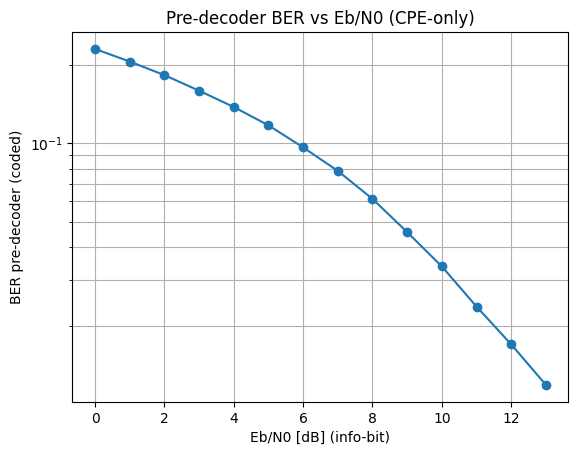

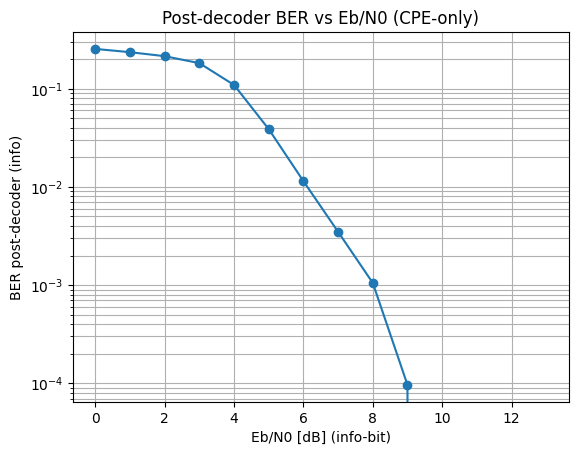

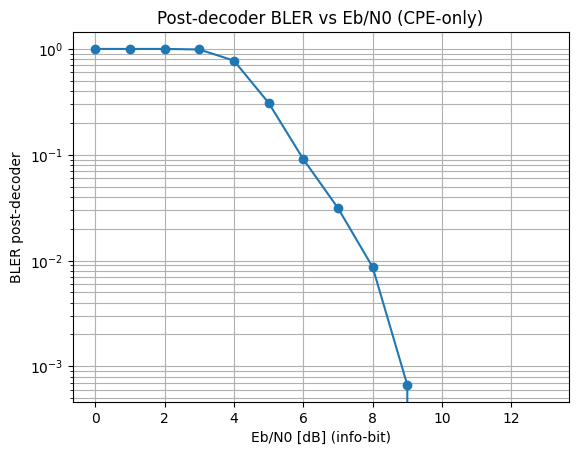


Running waveform: ofdm
Metrics: {'ber_pre_coded': 0.14008724689483643, 'ber_post_info': 0.11874088644981384, 'bler_post_info': 0.518666684627533}
Eb/N0=  0.0 dB | preBER=2.963e-01 | postBER=3.020e-01 | BLER=1.000e+00
Eb/N0=  1.0 dB | preBER=2.723e-01 | postBER=2.841e-01 | BLER=1.000e+00
Eb/N0=  2.0 dB | preBER=2.467e-01 | postBER=2.667e-01 | BLER=1.000e+00
Eb/N0=  3.0 dB | preBER=2.210e-01 | postBER=2.462e-01 | BLER=1.000e+00
Eb/N0=  4.0 dB | preBER=1.961e-01 | postBER=2.276e-01 | BLER=1.000e+00
Eb/N0=  5.0 dB | preBER=1.726e-01 | postBER=2.040e-01 | BLER=9.990e-01
Eb/N0=  6.0 dB | preBER=1.497e-01 | postBER=1.533e-01 | BLER=9.273e-01
Eb/N0=  7.0 dB | preBER=1.272e-01 | postBER=6.611e-02 | BLER=5.277e-01
Eb/N0=  8.0 dB | preBER=1.072e-01 | postBER=2.045e-02 | BLER=1.680e-01
Eb/N0=  9.0 dB | preBER=8.752e-02 | postBER=6.738e-03 | BLER=5.533e-02
Eb/N0= 10.0 dB | preBER=6.932e-02 | postBER=2.517e-03 | BLER=1.933e-02
Eb/N0= 11.0 dB | preBER=5.293e-02 | postBER=6.016e-04 | BLER=6.333e-03
E

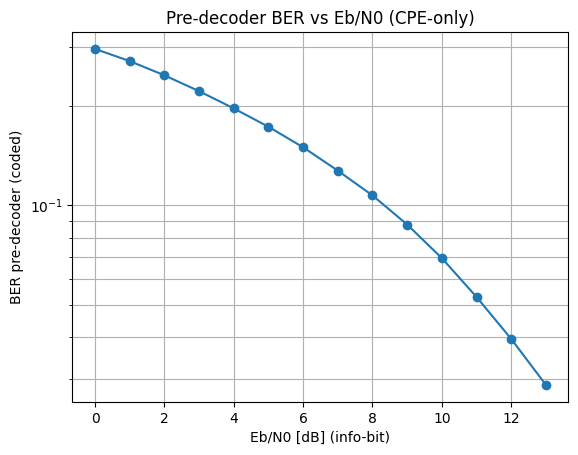

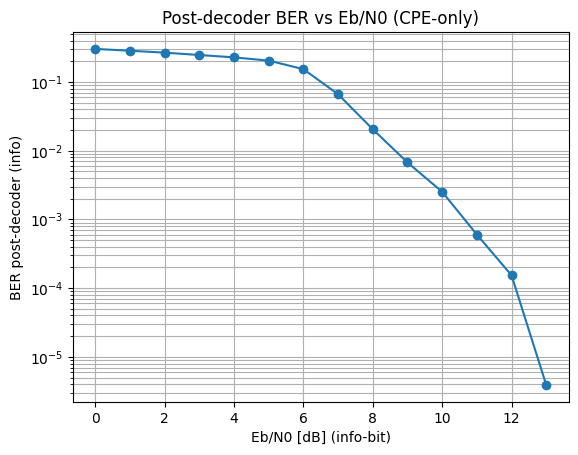

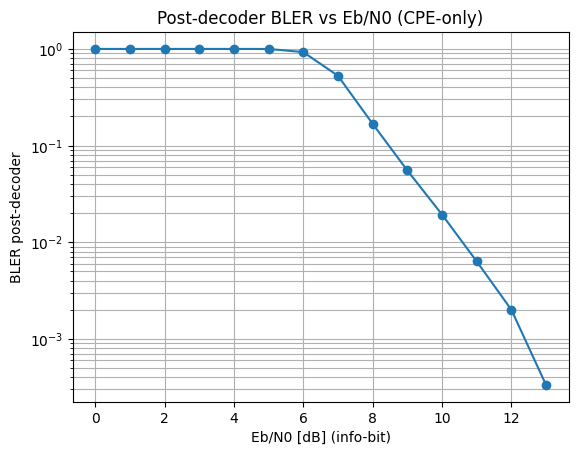

In [ ]:
if __name__ == "__main__":
    print("Sionna version:", getattr(sionna, "__version__", "unknown"))

    base = dict(
        num_examples=3000,
        bits_per_symbol=4,
        k=256,
        demap_method="app",
        dec_num_iter=15,
        cn_update="minsum",
        seed=46,
        channels_last=True,
        cfo_norm_min=-2e-4,
        cfo_norm_max=+2e-4,
        ebn0_db_min=0.0,
        ebn0_db_max=14.0,
        llr_noise_scaling=1.0,
        pilot_bits_per_symbol=2,   # QPSK pilots recommended
    )

    # --- Single-carrier config
    cfg_sc = SimConfig(**{
        **base,
        "waveform": "sc",
        "seq_length": 128,
        "pilot_len": 8,            # 8 pilot symbols (SC)
    })

    # --- OFDM config (seq_length must be num_data_symbols*fft_size)
    cfg_ofdm = SimConfig(**{
        **base,
        "waveform": "ofdm",
        "seq_length": 128,              # = 2*64
        "ofdm_fft_size": 64,
        "ofdm_cp_len": 16,
        "ofdm_num_pilot_symbols": 1,    # 1 pilot OFDM symbol
        "ofdm_num_data_symbols": 2,     # 2 data OFDM symbols -> 128 QAM data symbols
        "ofdm_l_min": 0,
    })

    for cfg in [cfg_sc, cfg_ofdm]:
        print("\n===============================")
        print("Running waveform:", cfg.waveform)

        full_tf = simulate_full_frames_tf(cfg)
        rx = classical_receiver(cfg, full_tf)
        print("Metrics:", rx["metrics"])

        ebn0_grid_db = list(range(0, 14))
        plot_ber_bler_vs_ebn0(cfg, ebn0_grid_db, n_per_point=3000)